I can open it
I can open it


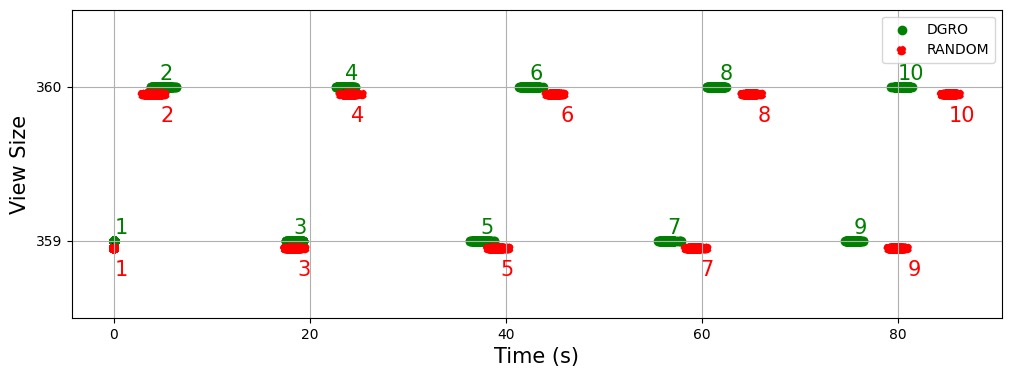

In [58]:
import re

# Define the regex pattern
pattern = r"Port (\d+) \+ view changes to size (\d+) at (\d+) ms"
pattern2 = r"Start time: (\d+) ms"

N = 100
k = 8



import matplotlib.pyplot as plt

# Plot the sorted list
labels = ['DGRO', 'RANDOM']
# prefix = ['', '_RANDOM_bk', '_bk']
# prefix = ['_bk', '_RANDOM_bk']
prefix = ['', '_RANDOM']
colors = ['g', 'r', 'b', 'purple']
linestyles = ['-', '--', '-.']
N_list = [360]
for N in N_list:
    fig, ax = plt.subplots(ncols=1, figsize=(12, 4))
    for gossip in [0, 1]:
        ViewchangeTime = {}
        ViewSize = {}
        Start_time = []
        ips = []
        start_time = 0
        latency_list = []
        # try:
        if True:
            with open(f"testrejoin_gossip={gossip}_numtest=5_N={N}.log") as f:
                print("I can open it")
                lines = f.readlines()
                for line in lines:
                    # Match the pattern
                    # print(line)
                    match = re.search(r"My IP:\s*([\d\.]+)", line)
                    if match:
                        ip_address = match.group(1)
                        ips.append(ip_address)
                        continue
                    match = re.match(pattern, line)
                    if match:
                        port, size, time_ms = map(int, match.groups())  # Extract values and convert to integers
                        if f"{ip_address}:{port}" not in ViewchangeTime.keys(): 
                            # ViewchangeTime[f"{ip_address}:{port}"] = [(time_ms - Start_time[0]) / 1000]
                            ViewchangeTime[f"{ip_address}:{port}"] = [(time_ms)]
                            ViewSize[f"{ip_address}:{port}"] = [size - 0.05 * gossip]
                        else:
                            ViewchangeTime[f"{ip_address}:{port}"].append((time_ms - ViewchangeTime[f"{ip_address}:{port}"][0]) / 1000)
                            ViewSize[f"{ip_address}:{port}"].append(size - 0.05 * gossip)
                            # ViewchangeTime[f"{ip_address}:{port}"].append((time_ms - Start_time[0]) / 1000)
                            # ViewSize[f"{ip_address}:{port}"].append(size - 0.05 * gossip)

                        continue
                    
                    match = re.match(pattern2, line)

                    if match:
                        start_time = int(match.group(1))
                        Start_time.append(start_time)
                        # print(start_time)
                        # offset = Start_time[]
                        # print(line, start_time)
                        # for key in ViewchangeTime.keys():
                        #     for i in range(len(ViewchangeTime[key])):
                        #         ViewchangeTime[key][i] = (ViewchangeTime[key][i] - start_time) / 1000
                        #         ViewSize[key][i] -= 0.01 * random
                            # latency_list.append(ViewchangeTime[key])
                        continue
                    
        
            # path_latency_sorted = sorted(latency_list)
            # print(path_latency_sorted[:5])
            # print(path_latency_sorted[:5], path_latency_sorted[-5:])
            first_scatter = True
            for port in ViewchangeTime.keys():
                ViewchangeTime[port][0] = 0
                ax.scatter(ViewchangeTime[port], ViewSize[port], linestyle=linestyles[gossip], 
                label=f"{labels[gossip]}" if first_scatter else None,
                color=colors[gossip])
                # print(ViewSize[port])
                if first_scatter:
                    for idx, x_value in enumerate(ViewchangeTime[port]):
                        y_value = ViewSize[port][idx]  # 对应的 y 值
                        ax.annotate(f"{idx + 1}",  # 标注内容为索引 ID
                                    (x_value, y_value),  # 标注的位置
                                    textcoords="offset points",  # 相对偏移
                                    xytext=(5, 5 - 25 * gossip),  # 偏移量，向右上方移动
                                    fontsize=15,  # 字体大小
                                    ha='center',
                                    color=colors[gossip])  # 水平居中

                first_scatter = False
            # assert 0
        # except:
        #     # print("Cannot find file", f"testrejoin_gossip={gossip}_numtest=4.log")
        #     print()
        #     pass 
    # ax.set_title('')
    ax.set_xlabel('Time (s)', fontdict={'fontsize':15})
    ax.set_ylabel('View Size', fontdict={'fontsize':15})
    # ax.set_xlim([0, 155])
    ax.set_ylim([N - 1.5, N + 0.5])
    ax.set_yticks([N - 1, N])
    ax.set_yticklabels([N - 1, N])
    ax.legend()
    ax.grid(True)
    plt.show()
    # fig.savefig(f'N={N}.pdf', bbox_inches='tight')


In [40]:
# fig.savefig(f'N=180_10_9_4_latency=250.pdf', bbox_inches='tight')
